In [ ]:
from datasets import load_dataset

ds = load_dataset("aarohanverma/simple-daily-conversations-cleaned")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/3.18M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/98472 [00:00<?, ? examples/s]

In [ ]:
ds

DatasetDict({
    train: Dataset({
        features: ['data'],
        num_rows: 98472
    })
})

In [ ]:
import pandas as pd
df = pd.DataFrame(ds['train'])

In [ ]:
df

,data
0,i usually enjoy the weekends but not this one
1,we tried to scare them away but they almost at...
2,i was nervous for no reason
3,have you tried to look into other providers to...
4,i do not need anything else in life
...,...
98467,i have a new storm shelter and food
98468,if only that was me
98469,not sure why i need to pay for it then
98470,i really wish i could have gone to cheesecake ...


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
import torch
from torch import nn
import math
import matplotlib.pyplot as plt

texts = df['data'].tolist()

# Convert text to TF-IDF vectors
vectorizer = TfidfVectorizer(max_features=100)
X = vectorizer.fit_transform(texts).toarray()

# Convert to torch tensor
train_data = torch.tensor(X, dtype=torch.float32)
train_data_length = train_data.shape[0]

train_labels = torch.zeros(train_data_length)

train_set = [
    (train_data[i], train_labels[i]) for i in range(train_data_length)
]

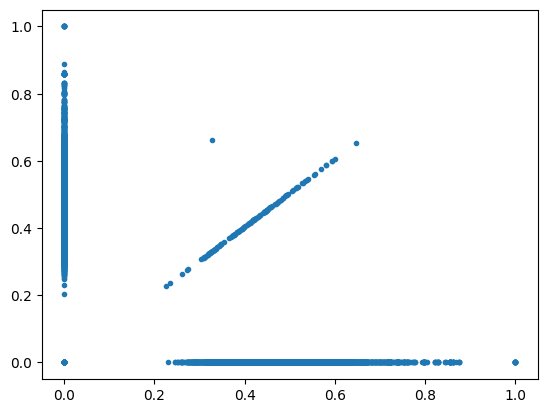

In [ ]:
plt.plot(train_data[:, 0], train_data[:, 1], ".")

In [ ]:
batch_size = 32
train_loader = torch.utils.data.DataLoader(
    train_set, batch_size=batch_size, shuffle=True
)

In [ ]:
class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(100, 256),   # changed 2 → 100
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 1),
            nn.Sigmoid(),
        )

    def forward(self, x):
        return self.model(x)

In [ ]:
latent_dim = 20

class Generator(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(latent_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 256),
            nn.ReLU(),
            nn.Linear(256, 100),   # output must match TF-IDF size
        )

    def forward(self, x):
        return self.model(x)

In [ ]:
generator = Generator()
discriminator = Discriminator()

In [ ]:
loss_function = nn.BCELoss()

optimizer_discriminator = torch.optim.Adam(discriminator.parameters(), lr=0.0002)
optimizer_generator = torch.optim.Adam(generator.parameters(), lr=0.0002)

num_epochs = 20

In [ ]:
k = 1   # number of discriminator updates per generator update

for epoch in range(num_epochs):
    for real_samples, _ in train_loader:

        batch_size = real_samples.size(0)

        real_labels = torch.ones((batch_size, 1))
        fake_labels = torch.zeros((batch_size, 1))

        # ------------------
        # Train Discriminator k times
        # ------------------
        for _ in range(k):

            discriminator.zero_grad()

            output_real = discriminator(real_samples)
            loss_real = loss_function(output_real, real_labels)

            latent_space_samples = torch.randn((batch_size, latent_dim))
            generated_samples = generator(latent_space_samples)

            output_fake = discriminator(generated_samples.detach())
            loss_fake = loss_function(output_fake, fake_labels)

            loss_discriminator = loss_real + loss_fake
            loss_discriminator.backward()
            optimizer_discriminator.step()

        # ------------------
        # Train Generator once
        # ------------------
        generator.zero_grad()

        latent_space_samples = torch.randn((batch_size, latent_dim))
        generated_samples = generator(latent_space_samples)

        output = discriminator(generated_samples)
        loss_generator = loss_function(output, real_labels)

        loss_generator.backward()
        optimizer_generator.step()

    print(f"Epoch {epoch+1}/{num_epochs} | "
          f"D Loss: {loss_discriminator.item():.4f} | "
          f"G Loss: {loss_generator.item():.4f}")

Epoch 1/20 | D Loss: 1.0097 | G Loss: 0.8618
Epoch 2/20 | D Loss: 1.2903 | G Loss: 1.1339
Epoch 3/20 | D Loss: 1.4252 | G Loss: 0.9915
Epoch 4/20 | D Loss: 1.2275 | G Loss: 0.8947
Epoch 5/20 | D Loss: 0.5057 | G Loss: 1.6830
Epoch 6/20 | D Loss: 0.6566 | G Loss: 1.9615
Epoch 7/20 | D Loss: 0.1750 | G Loss: 2.7069
Epoch 8/20 | D Loss: 0.1536 | G Loss: 2.6384
Epoch 9/20 | D Loss: 0.0894 | G Loss: 3.1060
Epoch 10/20 | D Loss: 0.2183 | G Loss: 2.6755
Epoch 11/20 | D Loss: 0.1486 | G Loss: 2.9773
Epoch 12/20 | D Loss: 0.0507 | G Loss: 3.2502
Epoch 13/20 | D Loss: 0.0808 | G Loss: 3.2767
Epoch 14/20 | D Loss: 0.4109 | G Loss: 3.8420
Epoch 15/20 | D Loss: 0.0391 | G Loss: 3.7810
Epoch 16/20 | D Loss: 0.0582 | G Loss: 3.4167
Epoch 17/20 | D Loss: 0.2525 | G Loss: 4.3110
Epoch 18/20 | D Loss: 0.1034 | G Loss: 4.3182
Epoch 19/20 | D Loss: 0.4627 | G Loss: 4.4672
Epoch 20/20 | D Loss: 0.1558 | G Loss: 3.1469


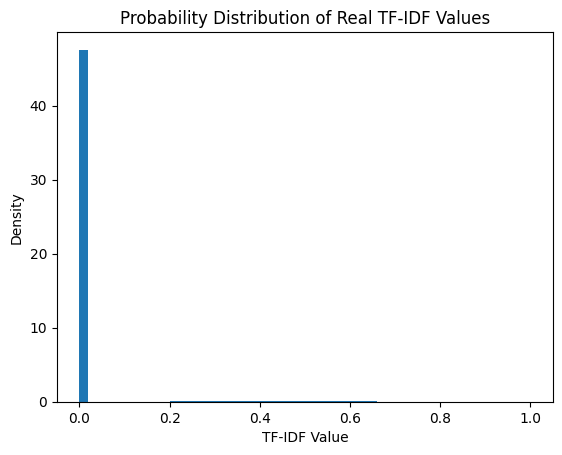

In [ ]:
real_values = train_data.detach().numpy().flatten()

plt.figure()
plt.hist(real_values, bins=50, density=True)
plt.title("Probability Distribution of Real TF-IDF Values")
plt.xlabel("TF-IDF Value")
plt.ylabel("Density")
plt.show()

In [ ]:
discriminator.eval()
generator.eval()

real_batch = train_data[:512]

latent_space_samples = torch.randn((512, latent_dim))
fake_batch = generator(latent_space_samples)

Dx = discriminator(real_batch).detach().numpy()
DGz = discriminator(fake_batch).detach().numpy()

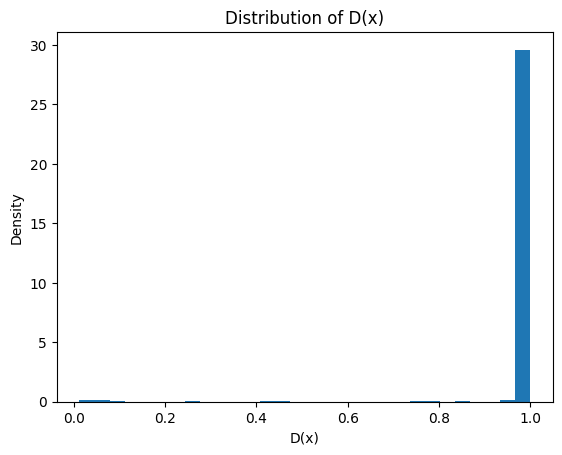

In [ ]:
plt.figure()
plt.hist(Dx, bins=30, density=True)
plt.title("Distribution of D(x)")
plt.xlabel("D(x)")
plt.ylabel("Density")
plt.show()

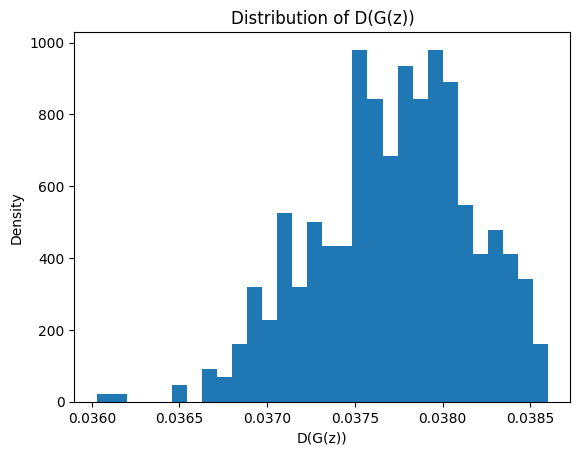

In [ ]:
plt.figure()
plt.hist(DGz, bins=30, density=True)
plt.title("Distribution of D(G(z))")
plt.xlabel("D(G(z))")
plt.ylabel("Density")
plt.show()